# 5.02 — HPO sweep and classification model evaluation

Documents the hyperparameter optimisation (HPO) sweep for
`albert.l1hs_l1pa2.v48.k17.salmon.seqlabel` and evaluates the resulting
classifier.

**Two sections, two data sources:**

| Section | Source | Grace needed? |
|---------|--------|---------------|
| A — Model evaluation | `models/albert.l1hs_l1pa2.v48.k17.salmon.seqlabel/{trainer_state,eval_results}.json` | no |
| B — HPO analysis | `results/hpo_classification/trials.csv` (exported after the sweep) | yes |

**Grace workflow (Section B):**
```bash
# 1. Run the sweep (8 workers × 1 trial each at 40 % data ≈ 34 h / trial)
SUBSAMPLE_FRAC=0.4 TRIALS_PER_WORKER=1 \
  STUDY_CLS=cls.gencode.v48.k17.salmon.seqlabel \
  CLS_TUNED_OUT=config/training/classification_final.gencode.v48.k17.salmon.seqlabel.tuned.json \
  bash scripts/slurm/submit_tuning.sh --run-config config/runs/salmon_seqlabel.yaml

# 2. After ALL array tasks finish, export the study:
python -m trap.modeling.tune export \
  --study-name cls.gencode.v48.k17.salmon.seqlabel \
  --storage $SCRATCH/trap_hpo/cls.gencode.v48.k17.salmon.seqlabel.journal \
  --out results/hpo_classification/trials.csv

# 3. Sync results/ to your local machine, then re-run Section B cells.
```


In [4]:
## Setup and helpers -----------------------------------------------------------
set.seed(3469)
suppressPackageStartupMessages({
  library(data.table)
  library(ggplot2)
  library(jsonlite)
})
options(repr.plot.width = 14, repr.plot.height = 8)
theme_set(theme_bw(base_size = 28.125))

model_dir   <- file.path("..", "models", "albert.l1hs_l1pa2.v48.k17.salmon.seqlabel")
results_dir <- file.path("..", "results", "hpo_classification")
figures_dir <- file.path("..", "reports", "figures", "hpo_classification")
dir.create(figures_dir, recursive = TRUE, showWarnings = FALSE)

classes <- c("L1HS", "L1PA", "NEGATIVE")
class_palette <- c("L1HS" = "#1F77B4", "L1PA" = "#FF7F0E", "NEGATIVE" = "#2CA02C")

save_fig <- function(plot, stem, width = 14, height = 8) {
  for (ext in c("png", "pdf")) {
    f <- file.path(figures_dir, paste0(stem, ".", ext))
    suppressMessages(ggsave(f, plot, width = width, height = height, dpi = 300, bg = "white"))
  }
  invisible(plot)
}


---
## Section 0 — Dataset composition

In [5]:
## Table: dataset composition (seqlabel, GENCODE v48) -------------------------
diag_path <- file.path("..", "data", "processed",
                        "gencode.v48.k17.salmon.seqlabel",
                        "diagnostics", "sample_size.json")
diag <- fromJSON(diag_path)
cb   <- diag$cls$class_balance

# HF split naming: train = training; test = validation (checkpoint selection);
# eval = held-out test set (final evaluation).
split_map <- list(
  list(key = "train", label = "Training"),
  list(key = "test",  label = "Validation"),
  list(key = "eval",  label = "Test (held-out)")
)

tbl_ds <- rbindlist(lapply(split_map, function(s) {
  sp    <- cb[[s$key]]
  n_pos <- sp$L1HS + sp$L1PA
  n_tot <- n_pos + sp$NEGATIVE
  data.table(
    Split              = s$label,
    L1HS               = formatC(sp$L1HS,     format = "d", big.mark = ","),
    L1PA               = formatC(sp$L1PA,     format = "d", big.mark = ","),
    NEGATIVE           = formatC(sp$NEGATIVE, format = "d", big.mark = ","),
    `LINE-1 (L1HS+L1PA)` = formatC(n_pos,    format = "d", big.mark = ","),
    Total              = formatC(n_tot,        format = "d", big.mark = ",")
  )
}))

# Totals row
tbl_ds <- rbind(tbl_ds, data.table(
  Split              = "Total",
  L1HS               = formatC(sum(sapply(cb, "[[", "L1HS")),     format = "d", big.mark = ","),
  L1PA               = formatC(sum(sapply(cb, "[[", "L1PA")),     format = "d", big.mark = ","),
  NEGATIVE           = formatC(sum(sapply(cb, "[[", "NEGATIVE")), format = "d", big.mark = ","),
  `LINE-1 (L1HS+L1PA)` = formatC(
    sum(sapply(cb, "[[", "L1HS")) + sum(sapply(cb, "[[", "L1PA")),
    format = "d", big.mark = ","
  ),
  Total              = formatC(
    sum(sapply(cb, function(x) x$L1HS + x$L1PA + x$NEGATIVE)),
    format = "d", big.mark = ","
  )
))
print(tbl_ds)
dir.create(results_dir, recursive = TRUE, showWarnings = FALSE)
fwrite(tbl_ds, file.path(results_dir, "dataset_composition.csv"))

             Split   L1HS      L1PA  NEGATIVE LINE-1 (L1HS+L1PA)     Total
            <char> <char>    <char>    <char>             <char>    <char>
1:        Training 60,639 2,439,877 2,161,900          2,500,516 4,662,416
2:      Validation 19,641   811,233   723,285            830,874 1,554,159
3: Test (held-out) 19,499   814,814   720,295            834,313 1,554,608
4:           Total 99,779 4,065,924 3,605,480          4,165,703 7,771,183


**Table. Dataset composition for ALBERT classifier training and evaluation.**

Composition of the simulated transcript-derived read dataset generated from GENCODE v48 and used to train, validate, and test the ALBERT sequence classifier. Reads were labeled as **L1HS**, **L1PA**, or **NEGATIVE** based on overlap with RepeatMasker LINE-1 annotations. L1HS and L1PA together represent LINE-1-positive reads, whereas NEGATIVE denotes reads not assigned to these LINE-1 classes. Dataset splitting was performed at the transcript level so that reads from the same transcript were assigned to only one split.

---
## Section A — Model evaluation


In [6]:
## Section A — Model evaluation ------------------------------------------------
## Load trainer state and eval results ----------------------------------------
ts  <- fromJSON(file.path(model_dir, "trainer_state.json"))
er  <- fromJSON(file.path(model_dir, "eval_results.json"))

# Flatten log_history. Because its rows have heterogeneous keys (train-step rows,
# eval rows, and a final summary row), jsonlite may already simplify it to a
# data.frame; older/other settings return a list of named rows. Handle both so
# the eval columns (e.g. eval_f1) are present regardless.
lh <- ts$log_history
log_h <- if (is.data.frame(lh)) {
  as.data.table(lh)
} else {
  rbindlist(lapply(lh, as.list), fill = TRUE)
}
eval_h <- log_h[!is.na(eval_f1), .(
  epoch     = as.integer(epoch),
  eval_f1   = as.numeric(eval_f1),
  eval_loss = as.numeric(eval_loss)
)]
best_epoch <- eval_h[which.max(eval_f1), epoch]
cat(sprintf("Best epoch: %d  (macro F1 = %.4f)\n", best_epoch, max(eval_h$eval_f1)))


Best epoch: 7  (macro F1 = 0.8650)


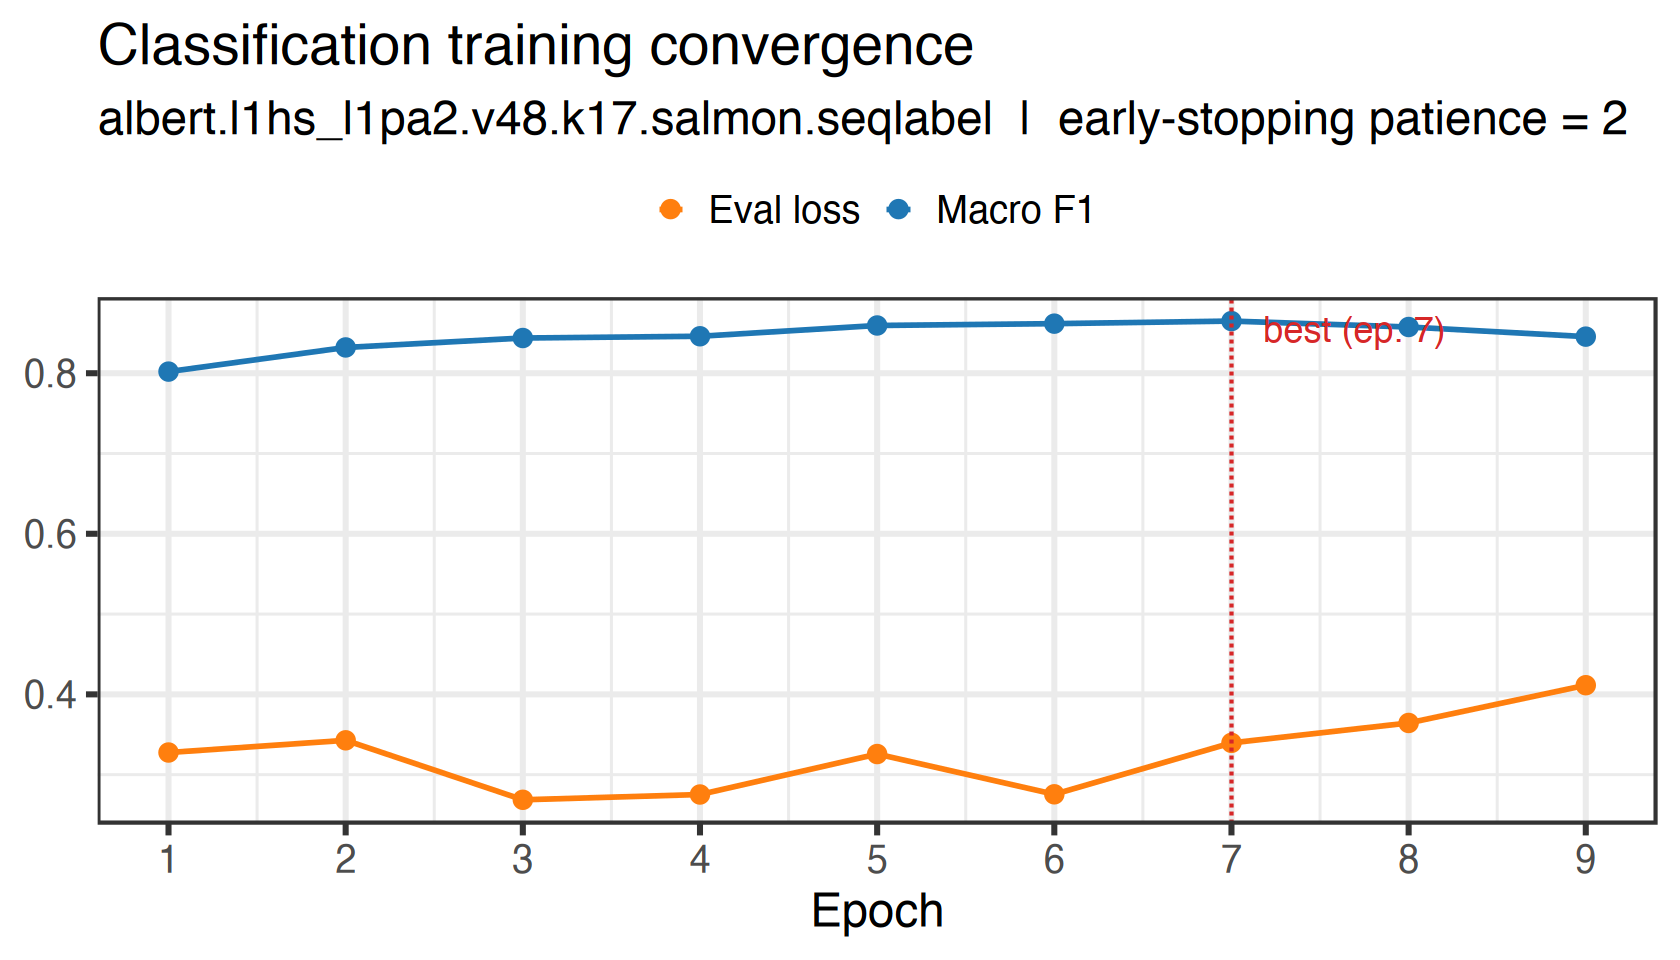

In [7]:
## Fig: learning curve (macro F1 + eval loss vs epoch) -----------------------
long_lc <- melt(eval_h, id.vars = "epoch",
                measure.vars = c("eval_f1", "eval_loss"),
                variable.name = "metric", value.name = "value")
long_lc[, label := fifelse(metric == "eval_f1", "Macro F1", "Eval loss")]

p_lc <- ggplot(long_lc, aes(epoch, value, color = label, group = label)) +
  geom_line(linewidth = 1.2) +
  geom_point(size = 3.5) +
  geom_vline(xintercept = best_epoch, linetype = "dashed",
             color = "#D62728", linewidth = 0.9) +
  annotate("text",
           x = best_epoch + 0.18, y = max(long_lc$value) - 0.01,
           label = sprintf("best (ep. %d)", best_epoch),
           hjust = 0, size = 7.5, color = "#D62728") +
  scale_x_continuous(breaks = eval_h$epoch) +
  scale_color_manual(values = c("Macro F1" = "#1F77B4", "Eval loss" = "#FF7F0E")) +
  labs(x = "Epoch", y = NULL, color = NULL,
       title = "Classification training convergence",
       subtitle = "albert.l1hs_l1pa2.v48.k17.salmon.seqlabel  |  early-stopping patience = 2") +
  theme(legend.position = "top")
save_fig(p_lc, "learning_curve")
p_lc


**Figure. Training performance of the ALBERT sequence classifier.**

Validation performance of the ALBERT classifier across training epochs. Macro F1 score and evaluation loss are shown for each epoch, and the dashed line marks the checkpoint with the best validation performance. Training stopped after performance no longer improved.

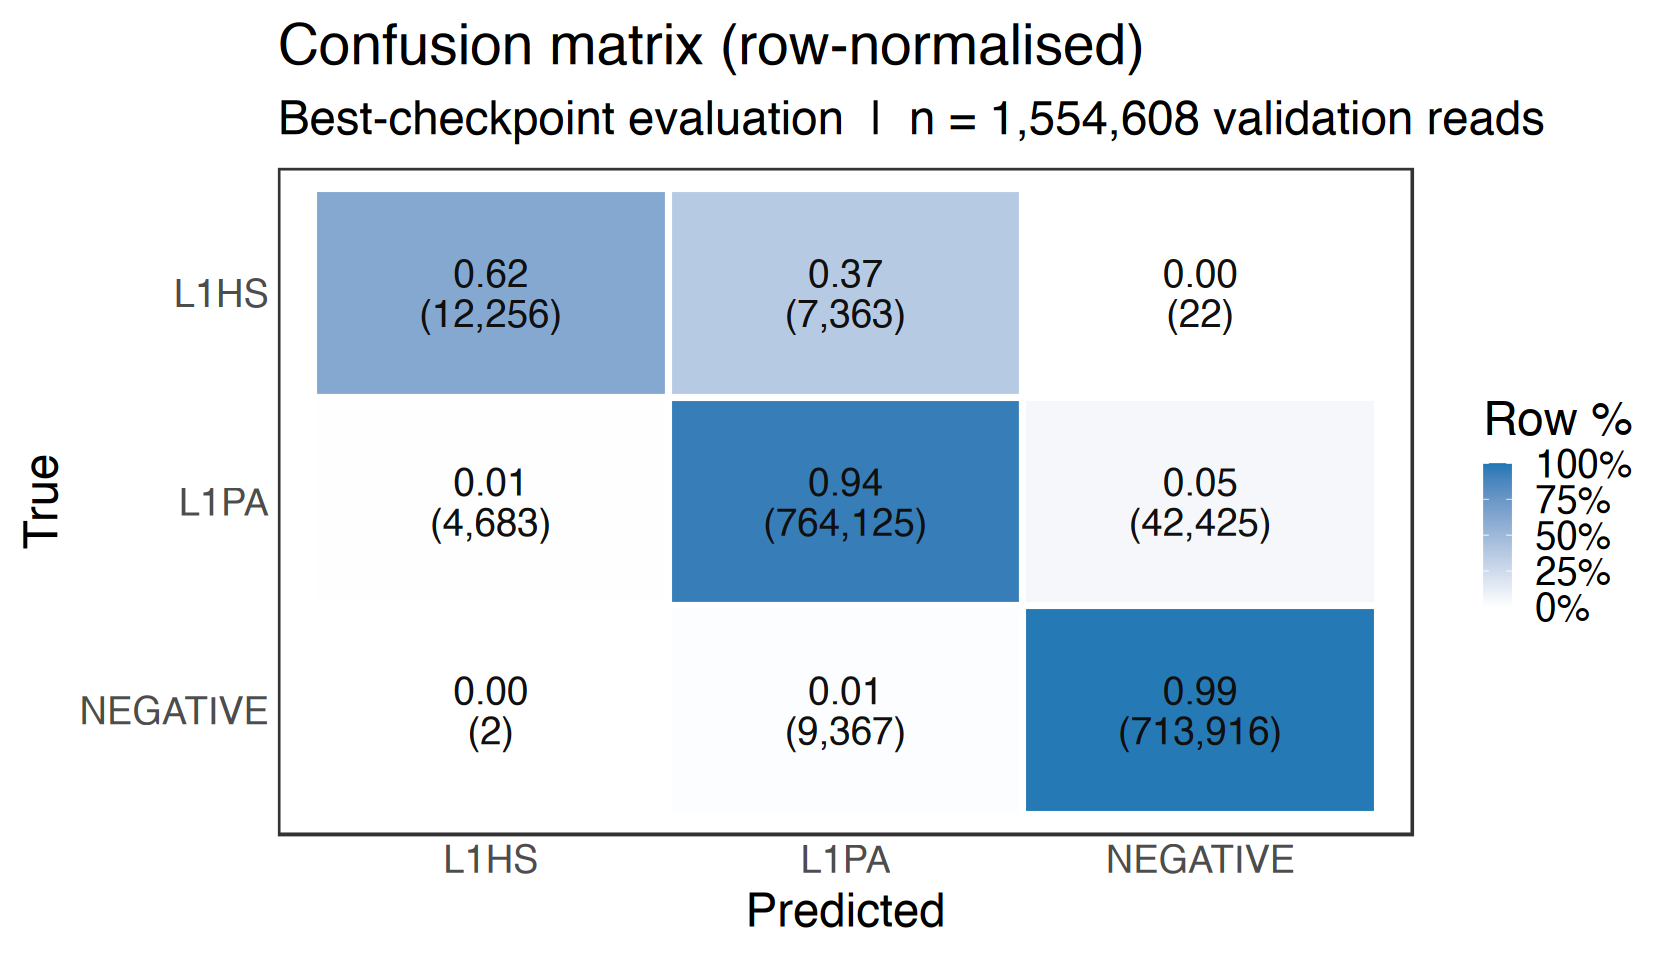

In [8]:
## Fig: confusion matrix (row-normalised) -------------------------------------
cm_raw <- outer(classes, classes, Vectorize(function(r, pred)
  er[[paste0("eval_cm_", r, "_as_", pred)]]
))
dimnames(cm_raw) <- list(True = classes, Predicted = classes)
cm_dt <- as.data.table(as.table(cm_raw))
setnames(cm_dt, c("True", "Predicted", "N"))
cm_dt[, Fraction := N / sum(N), by = True]
cm_dt[, CellLabel := sprintf("%.2f\n(%s)", Fraction,
                              formatC(N, format = "d", big.mark = ","))]

p_cm <- ggplot(cm_dt, aes(Predicted, True, fill = Fraction)) +
  geom_tile(color = "white", linewidth = 1.5) +
  geom_text(aes(label = CellLabel), size = 8, lineheight = 0.88, color = "#101010") +
  scale_fill_gradient(low = "white", high = "#1F77B4", limits = c(0, 1),
                      name = "Row %",
                      labels = function(x) paste0(round(x * 100), "%")) +
  scale_y_discrete(limits = rev(classes)) +
  labs(title = "Confusion matrix (row-normalised)",
       subtitle = "Best-checkpoint evaluation  |  n = 1,554,608 validation reads") +
  theme(panel.grid = element_blank(), axis.ticks = element_blank())
save_fig(p_cm, "confusion_matrix", width = 11, height = 8)
p_cm


**Figure. Confusion matrix for ALBERT classifier predictions.**

Row-normalized confusion matrix showing how often reads from each true class were assigned to each predicted class by the best ALBERT classifier. Correct classifications appear along the diagonal. Most errors occurred between L1HS and L1PA, consistent with the high sequence similarity between these LINE-1 subfamilies.

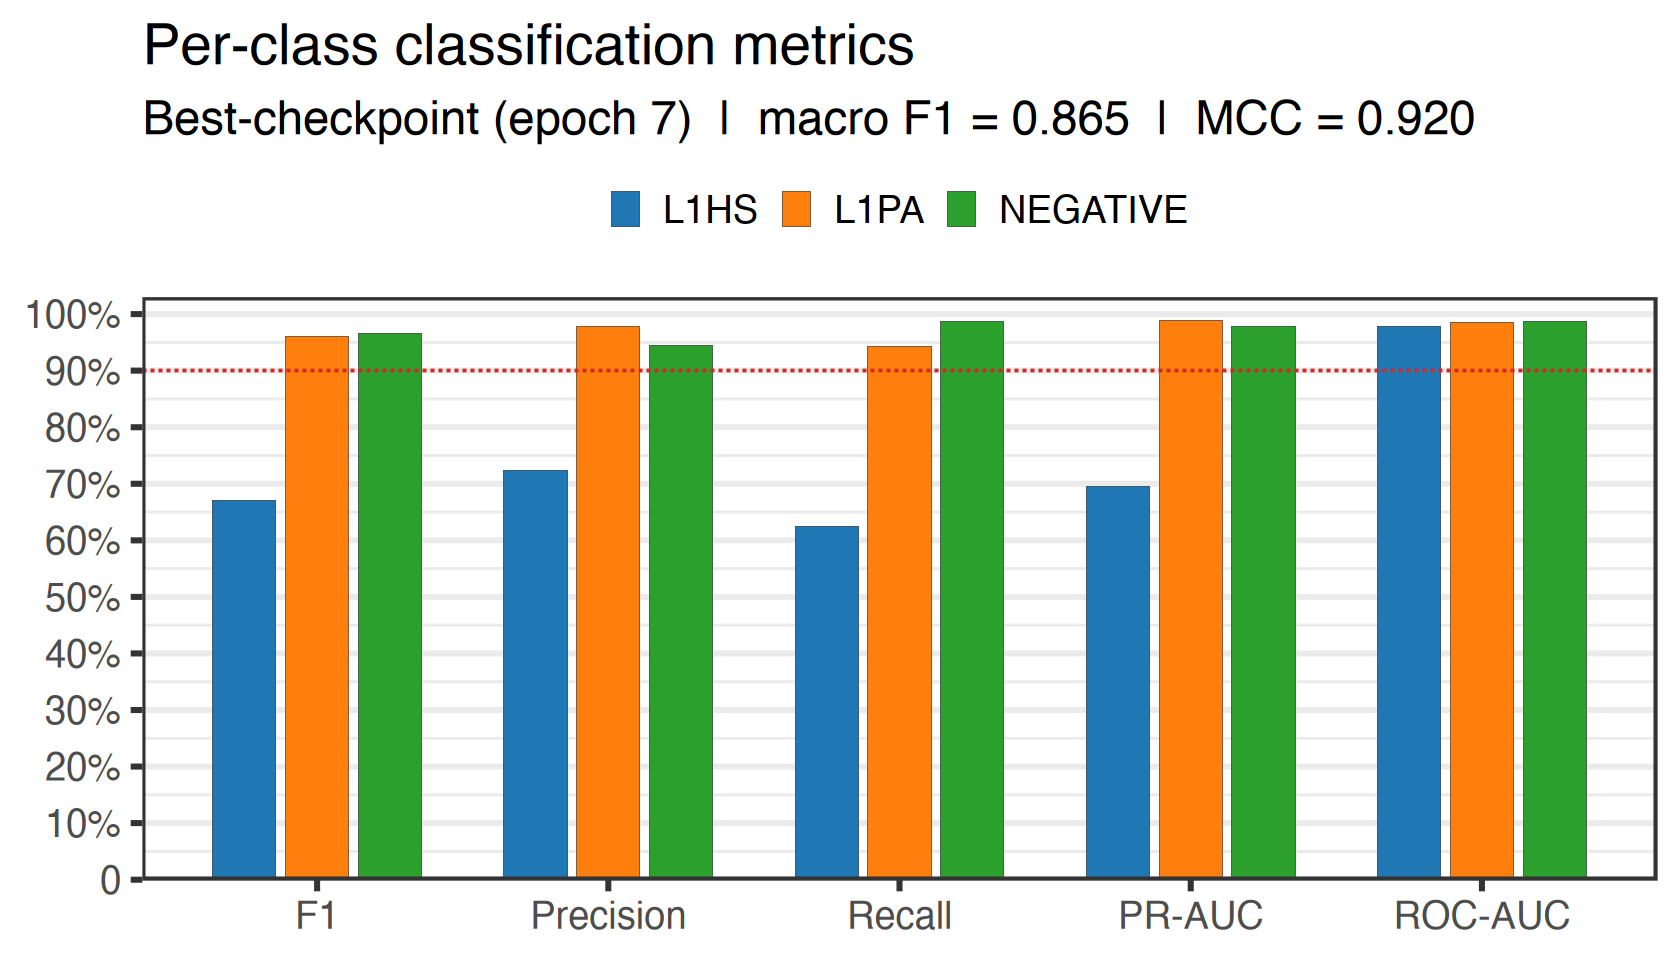

In [9]:
## Fig: per-class performance metrics ----------------------------------------
metric_keys   <- c("f1", "precision", "recall", "pr_auc", "roc_auc")
metric_labels <- c("F1", "Precision", "Recall", "PR-AUC", "ROC-AUC")

perf <- rbindlist(lapply(seq_along(metric_keys), function(i) {
  rbindlist(lapply(classes, function(cl) {
    key <- paste0("eval_", metric_keys[i], "_", cl)
    data.table(class = cl, metric = metric_labels[i], value = er[[key]])
  }))
}))
perf[, class  := factor(class,  levels = classes)]
perf[, metric := factor(metric, levels = metric_labels)]

p_perf <- ggplot(perf, aes(metric, value, fill = class)) +
  geom_col(position = position_dodge(width = 0.75), width = 0.65,
           color = "grey30", linewidth = 0.15) +
  geom_hline(yintercept = 0.9, linetype = "dashed",
             color = "#D62728", linewidth = 0.8) +
  scale_fill_manual(values = class_palette, name = NULL) +
  scale_y_continuous(limits = c(0, 1.03), expand = c(0, 0),
                     breaks = seq(0, 1, 0.1),
                     labels = function(x) ifelse(x == 0, "0", sprintf("%.0f%%", x * 100))) +
  labs(x = NULL, y = NULL,
       title = "Per-class classification metrics",
       subtitle = "Best-checkpoint (epoch 7)  |  macro F1 = 0.865  |  MCC = 0.920") +
  theme(legend.position = "top",
        panel.grid.major.x = element_blank())
save_fig(p_perf, "per_class_metrics", width = 16, height = 8.5)
p_perf


**Figure. Per-class classification performance.**

Classification performance of the best ALBERT model for each output class. Bars show F1 score, precision, recall, PR-AUC, and ROC-AUC for L1HS, L1PA, and NEGATIVE reads. The dashed line marks a reference value of 0.90 to help compare class-level performance.

In [10]:
## Table: per-class and aggregate metrics (replaces Table 3 in manuscript) ---
all_metrics <- c("f1", "precision", "recall", "pr_auc", "roc_auc")
all_labels  <- c("F1", "Precision", "Recall", "PR-AUC", "ROC-AUC")

# Per-class rows (include support N)
rows_per_class <- rbindlist(lapply(classes, function(cl) {
  vals <- sapply(all_metrics, function(m) {
    v <- er[[paste0("eval_", m, "_", cl)]]
    sprintf("%.3f", if (is.null(v)) NA_real_ else v)
  })
  n <- er[[paste0("eval_support_", cl)]]
  as.data.table(as.list(c(
    Class = cl,
    setNames(vals, all_labels),
    N = formatC(n, format = "d", big.mark = ",")
  )))
}))

# Aggregate row (macro averages)
macro_vals <- c(
  F1        = er$eval_f1,
  Precision = er$eval_precision,
  Recall    = er$eval_recall,
  `PR-AUC`  = er$eval_pr_auc,
  `ROC-AUC` = er$eval_roc_auc
)
row_macro <- as.data.table(as.list(c(
  Class = "Macro avg",
  sapply(names(macro_vals), function(m) sprintf("%.3f", macro_vals[[m]])),
  N = formatC(er$eval_samples, format = "d", big.mark = ",")
)))

tbl <- rbind(rows_per_class, row_macro)
cat("Per-class and aggregate metrics (best checkpoint, epoch", best_epoch, "):\n")
print(tbl)

# Additional aggregate stats for the manuscript
cat(sprintf(
  "\nOverall accuracy:    %.3f\nBalanced accuracy:   %.3f\nCohen's kappa:       %.3f\nMCC:                 %.3f\n",
  er$eval_accuracy, er$eval_balanced_accuracy,
  er$eval_cohen_kappa, er$eval_mcc
))

dir.create(results_dir, recursive = TRUE, showWarnings = FALSE)
fwrite(tbl, file.path(results_dir, "per_class_metrics_table.csv"))

Per-class and aggregate metrics (best checkpoint, epoch 7 ):
       Class     F1 Precision Recall PR-AUC ROC-AUC         N
      <char> <char>    <char> <char> <char>  <char>    <char>
1:      L1HS  0.670     0.723  0.624  0.696   0.978    19,641
2:      L1PA  0.960     0.979  0.942  0.988   0.985   811,233
3:  NEGATIVE  0.965     0.944  0.987  0.979   0.988   723,285
4: Macro avg  0.865     0.882  0.851  0.888   0.984 1,554,608

Overall accuracy:    0.959
Balanced accuracy:   0.851
Cohen's kappa:       0.920
MCC:                 0.920


**Table. Classification performance of the ALBERT sequence classifier.**

Per-class and aggregate performance of the best ALBERT classifier on the held-out test set. Metrics include F1 score, precision, recall, PR-AUC, and ROC-AUC for each class, together with macro-averaged performance across classes. Overall accuracy, Cohen's kappa, and Matthews correlation coefficient are reported as summary measures of classifier performance.

---
## Section B — HPO analysis

> **Prerequisite:** run the sweep on Grace and sync `results/hpo_classification/trials.csv` to this machine before running the cells below.


In [11]:
## Section B — HPO analysis ----------------------------------------------------
## Load trials CSV (generated on Grace after the sweep) -----------------------
trials_path <- file.path(results_dir, "trials.csv")
if (!file.exists(trials_path)) {
  stop(paste0(
    "trials.csv not found.\n",
    "Run on Grace:\n",
    "  python -m trap.modeling.tune export \\\n",
    "    --study-name cls.gencode.v48.k17.salmon.seqlabel \\\n",
    "    --storage $SCRATCH/trap_hpo/cls.gencode.v48.k17.salmon.seqlabel.journal \\\n",
    "    --out results/hpo_classification/trials.csv\n",
    "Then sync results/ to this machine and re-run."
  ))
}
trials  <- fread(trials_path)
cat(sprintf("Loaded %d trials; %d COMPLETE\n",
            nrow(trials), sum(trials$state == "COMPLETE")))

# Rename Optuna's params_* columns to bare names for convenience
setnames(trials,
  old = c("params_learning_rate", "params_weight_decay",
          "params_warmup_ratio", "params_per_device_train_batch_size",
          "params_num_train_epochs"),
  new = c("learning_rate", "weight_decay",
          "warmup_ratio", "batch_size", "num_epochs"),
  skip_absent = TRUE
)
ok <- trials[state == "COMPLETE"]
cat(sprintf("Best trial: F1 = %.4f  (LR = %.2e, wd = %.4f, warmup = %.2f, bs = %d, epochs = %d)\n",
            max(ok$value),
            ok[which.max(value), learning_rate],
            ok[which.max(value), weight_decay],
            ok[which.max(value), warmup_ratio],
            ok[which.max(value), batch_size],
            ok[which.max(value), num_epochs]))


Loaded 8 trials; 5 COMPLETE
Best trial: F1 = 0.8393  (LR = 1.57e-05, wd = 0.2916, warmup = 0.10, bs = 16, epochs = 5)


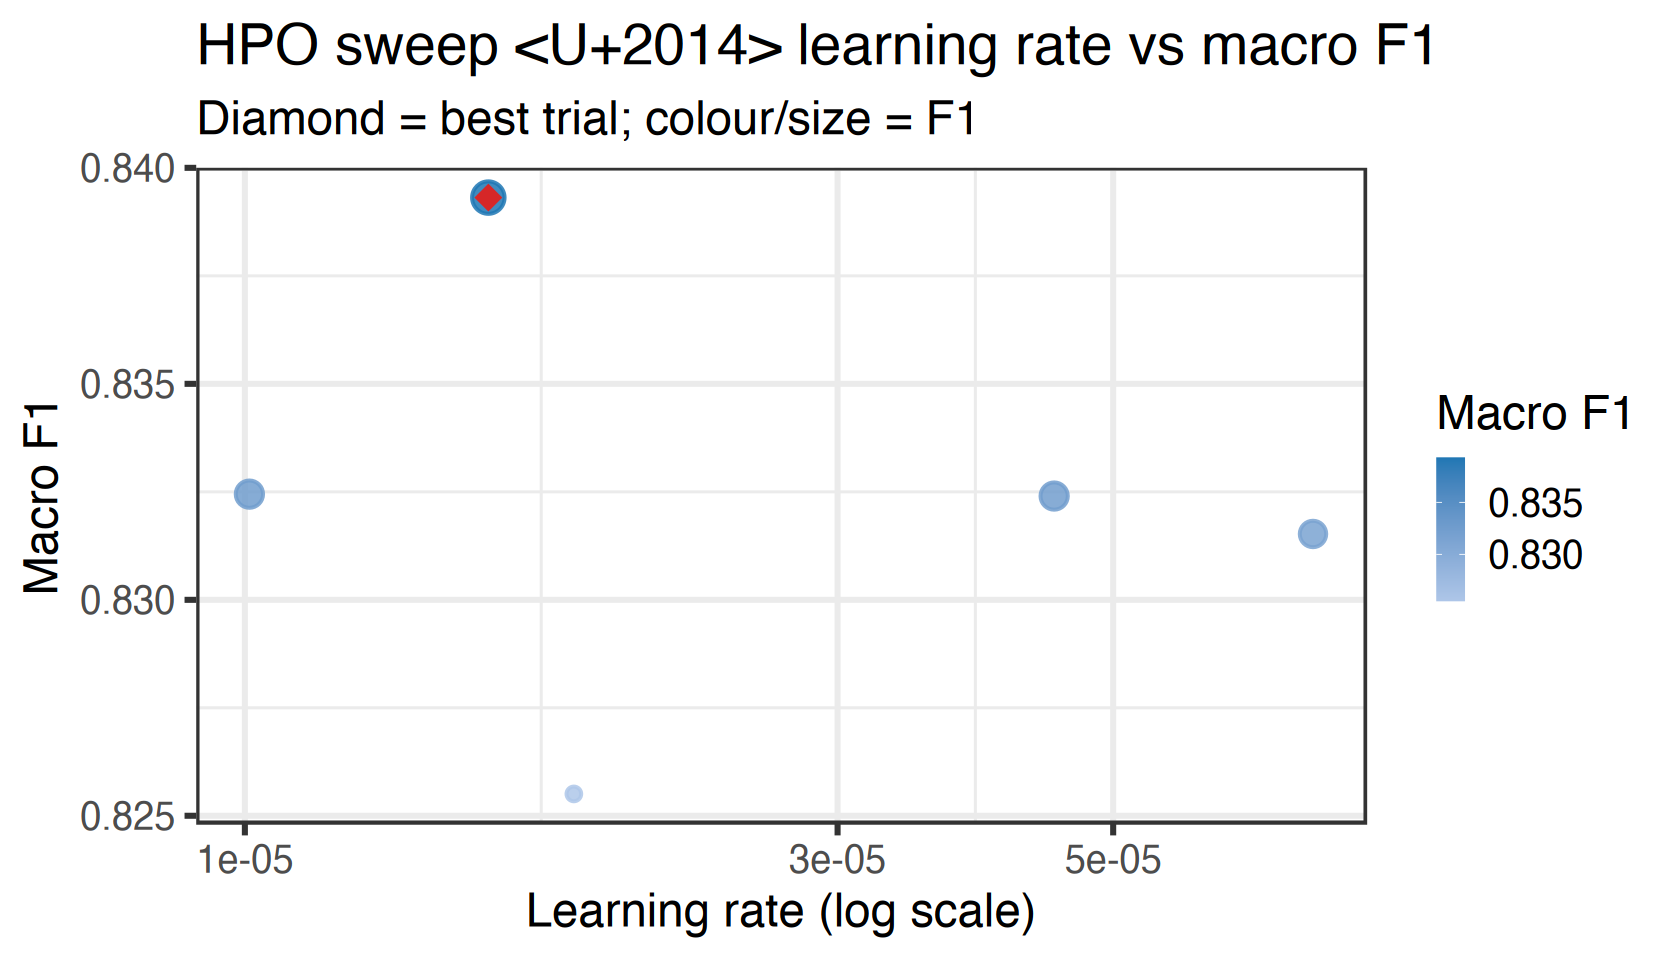

In [12]:
## Fig: learning rate vs macro F1 (most critical HP) -------------------------
p_lr <- ggplot(ok, aes(learning_rate, value)) +
  geom_point(aes(color = value, size = value), alpha = 0.85) +
  geom_point(data = ok[which.max(value)],
             aes(learning_rate, value), shape = 18, size = 7,
             color = "#D62728") +
  scale_x_log10(labels = function(x) sprintf("%.0e", x)) +
  scale_color_gradient(low = "#AEC6E8", high = "#1F77B4", name = "Macro F1") +
  scale_size_continuous(range = c(3, 8), guide = "none") +
  labs(x = "Learning rate (log scale)", y = "Macro F1",
       title = "HPO sweep — learning rate vs macro F1",
       subtitle = "Diamond = best trial; colour/size = F1") +
  theme(legend.position = "right")
save_fig(p_lr, "hpo_lr_vs_f1", width = 14, height = 8)
p_lr


**Figure. Effect of learning rate on classifier performance during hyperparameter optimization.**

Relationship between learning rate and macro F1 score across completed hyperparameter optimization trials. Each point represents one trial, and the highlighted point marks the best-performing configuration. The strongest-performing models were obtained at intermediate learning rates.

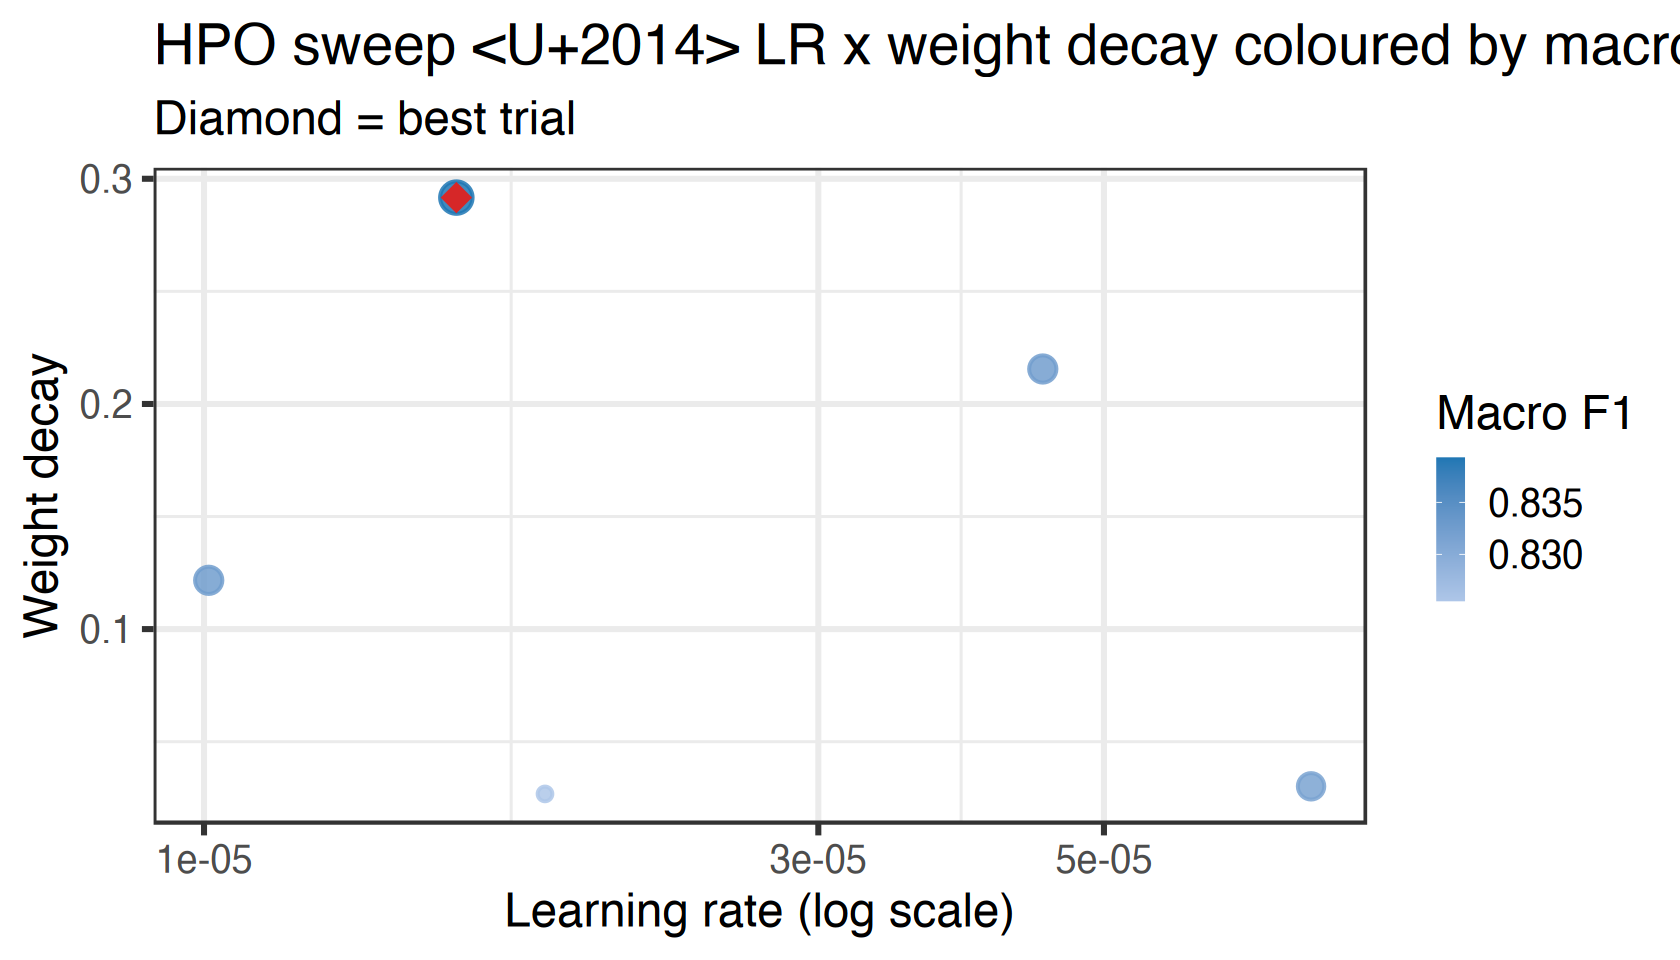

In [13]:
## Fig: LR x weight_decay contour (two most critical HPs) -------------------
p_contour <- ggplot(ok, aes(learning_rate, weight_decay, color = value)) +
  geom_point(aes(size = value), alpha = 0.85) +
  geom_point(data = ok[which.max(value)],
             shape = 18, size = 8, color = "#D62728") +
  scale_x_log10(labels = function(x) sprintf("%.0e", x)) +
  scale_color_gradient(low = "#AEC6E8", high = "#1F77B4", name = "Macro F1") +
  scale_size_continuous(range = c(3, 8), guide = "none") +
  labs(x = "Learning rate (log scale)", y = "Weight decay",
       title = "HPO sweep — LR x weight decay coloured by macro F1",
       subtitle = "Diamond = best trial") +
  theme(legend.position = "right")
save_fig(p_contour, "hpo_lr_wd_contour", width = 14, height = 8)
p_contour


**Figure. Joint effect of learning rate and weight decay during hyperparameter optimization.**

Classifier performance across combinations of learning rate and weight decay tested during hyperparameter optimization. Each point represents one completed trial, with color indicating macro F1 score. The highlighted point marks the best-performing configuration.

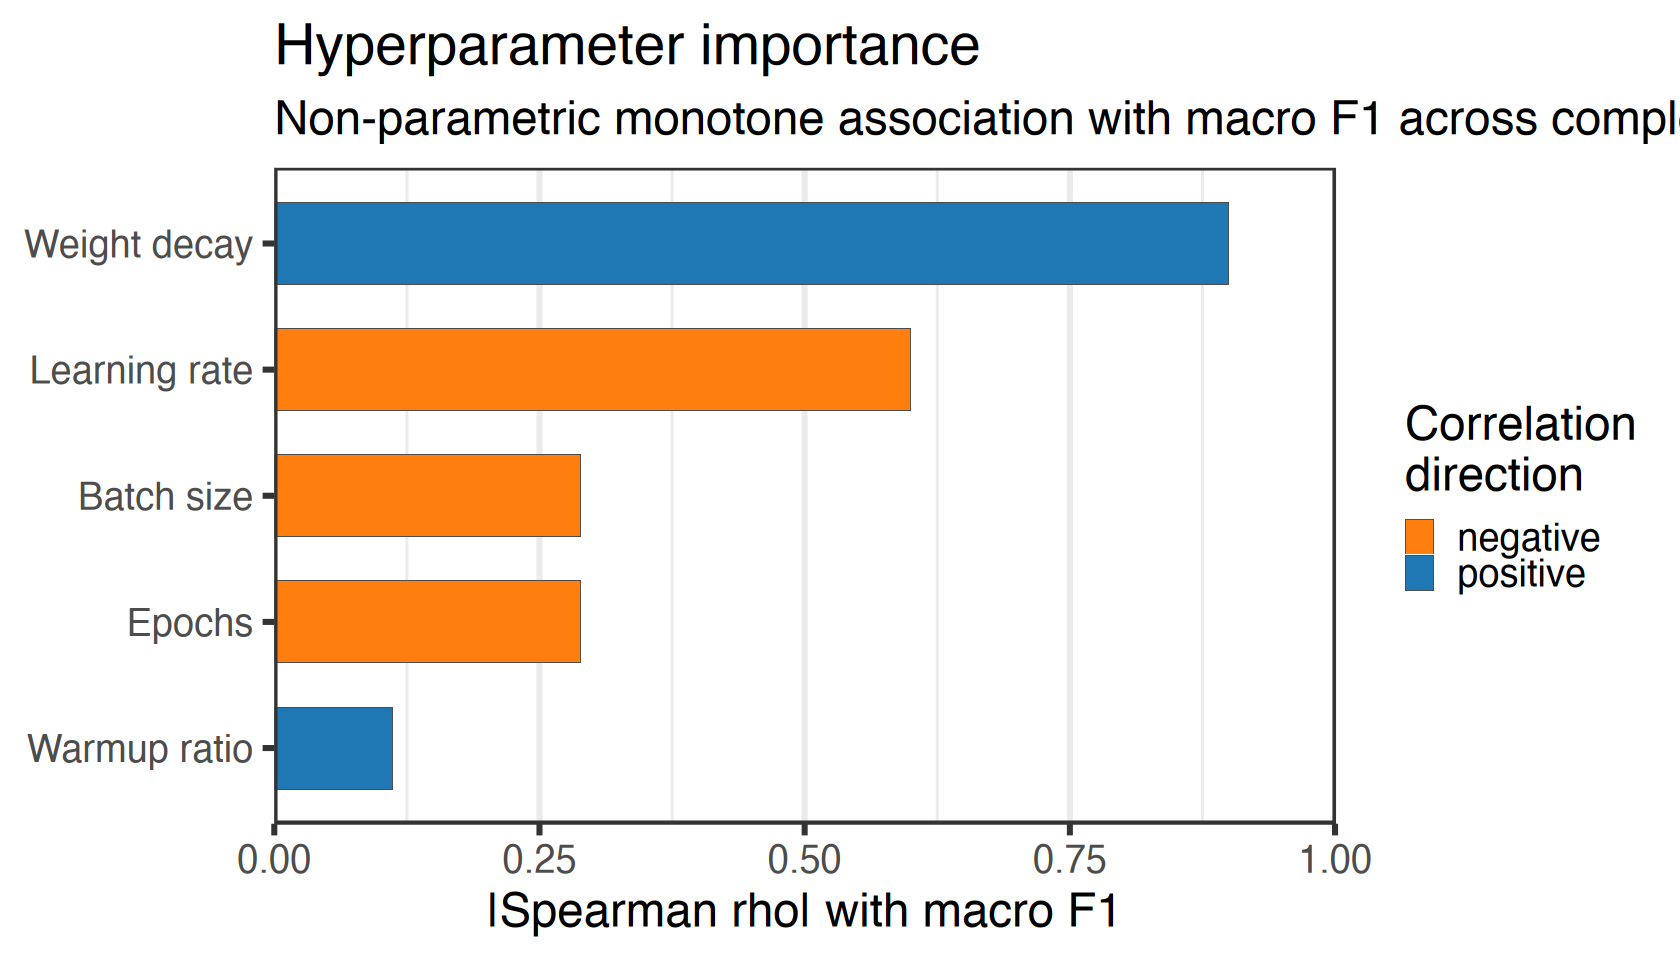

In [14]:
## Fig: hyperparameter importance (Spearman |rho| with macro F1) -------------
# Simple non-parametric importance: |Spearman rho| with F1 for each numeric HP.
hp_cols <- c("learning_rate", "weight_decay", "warmup_ratio",
             "batch_size", "num_epochs")
hp_labels <- c("Learning rate", "Weight decay", "Warmup ratio",
               "Batch size", "Epochs")
importance <- rbindlist(lapply(seq_along(hp_cols), function(i) {
  col <- hp_cols[i]
  if (!col %in% names(ok) || sum(!is.na(ok[[col]])) < 3) return(NULL)
  rho <- cor(ok[[col]], ok$value, method = "spearman", use = "complete.obs")
  data.table(param = hp_labels[i], rho = rho, abs_rho = abs(rho),
             direction = ifelse(rho >= 0, "positive", "negative"))
}))
importance <- importance[order(-abs_rho)]
importance[, param := factor(param, levels = rev(param))]

p_imp <- ggplot(importance, aes(abs_rho, param, fill = direction)) +
  geom_col(width = 0.65, color = "grey30", linewidth = 0.2) +
  geom_vline(xintercept = 0, linewidth = 0.5, color = "grey50") +
  scale_fill_manual(values = c("positive" = "#1F77B4", "negative" = "#FF7F0E"),
                    name = "Correlation
direction") +
  scale_x_continuous(limits = c(0, 1), expand = c(0, 0)) +
  labs(x = "|Spearman rho| with macro F1", y = NULL,
       title = "Hyperparameter importance",
       subtitle = "Non-parametric monotone association with macro F1 across completed trials") +
  theme(panel.grid.major.y = element_blank())
save_fig(p_imp, "hpo_importance", width = 14, height = 6)
p_imp


**Figure. Relative importance of hyperparameters during optimization.**

Relative association between each tested hyperparameter and classifier performance. Importance was estimated from the strength of the relationship between each hyperparameter and macro F1 score across completed trials. Learning rate showed the strongest association with model performance.

Warning message in melt.data.table(ok[, c("number", "value", ..hp_num_present)], :
"las 'measure.vars' [learning_rate, weight_decay, warmup_ratio, batch_size, ...] no son todas del mismo tipo. Por orden de jerarqu'ia, la columna de valores de datos "fundida" ser'a del tipo 'double'. Todas las variables de medida que no sean del tipo 'double' tambi'en ser'an coercionadas. Consulte los detalles en ?melt.data.table para obtener m'as informaci'on sobre la coerci'on."


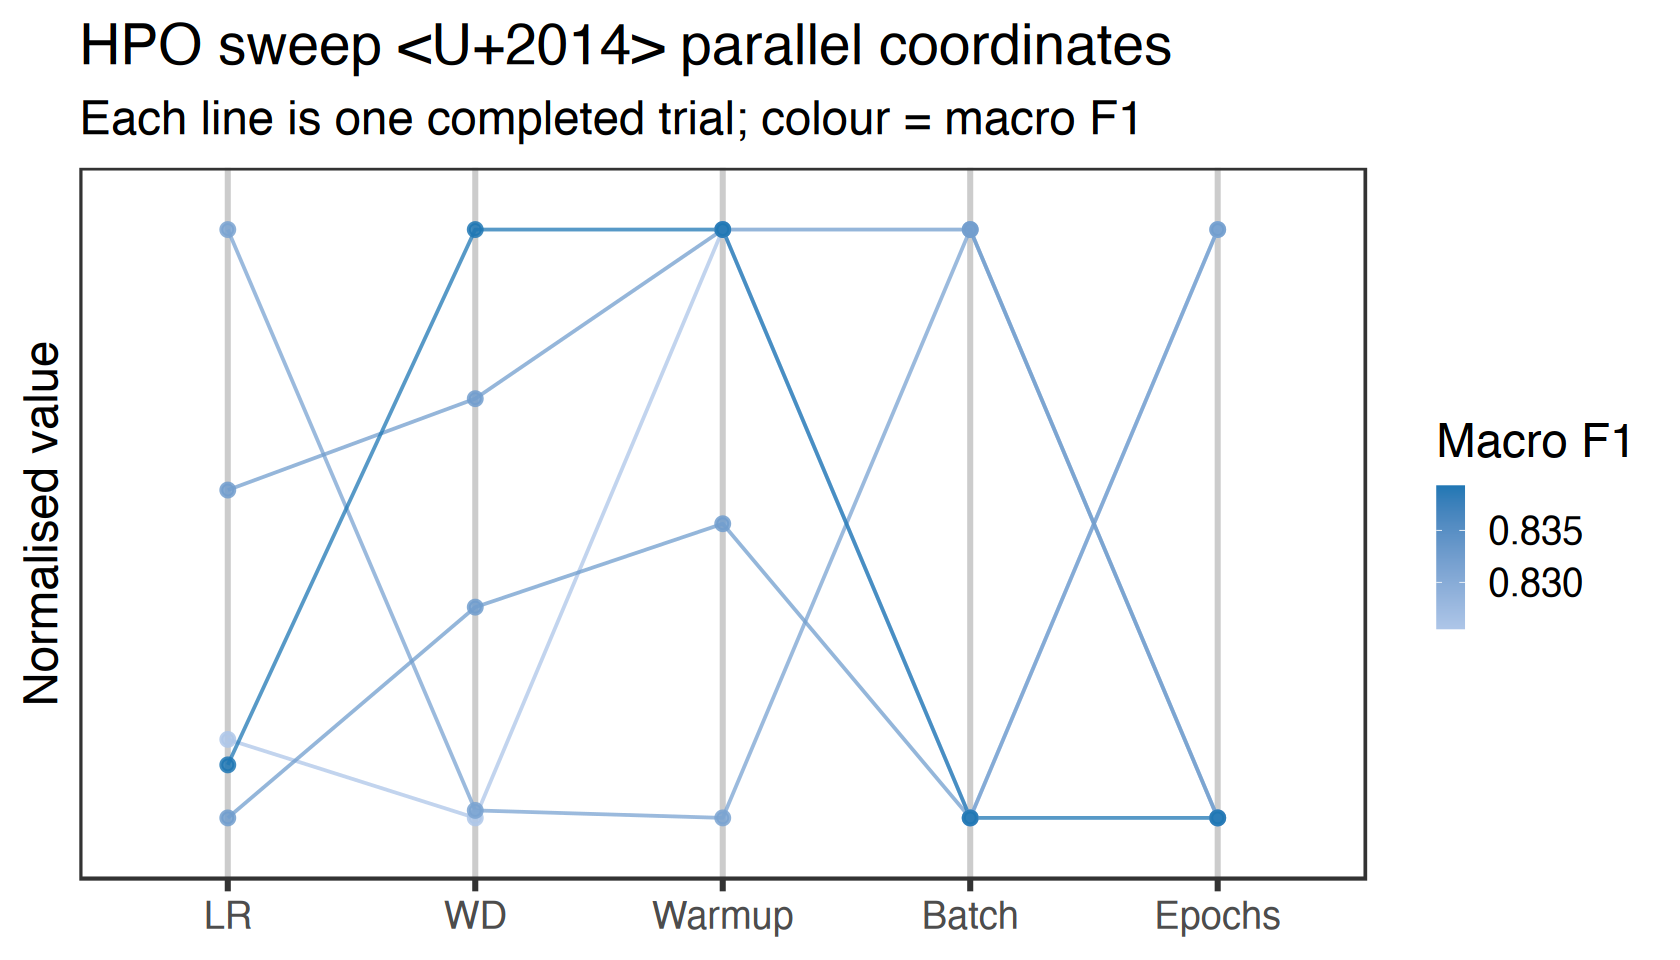

In [15]:
## Fig: parallel coordinates — all completed trials ---------------------------
# Normalise each numeric HP to [0, 1] for the parallel axis.
norm01 <- function(x) {
  r <- range(x, na.rm = TRUE)
  if (diff(r) == 0) return(rep(0.5, length(x)))
  (x - r[1]) / diff(r)
}
hp_num <- c("learning_rate", "weight_decay", "warmup_ratio",
            "batch_size", "num_epochs")
hp_num_present <- intersect(hp_num, names(ok))

par_long <- melt(
  ok[, c("number", "value", ..hp_num_present)],
  id.vars = c("number", "value"),
  variable.name = "param", value.name = "raw_value"
)
par_long[, norm_value := norm01(raw_value), by = param]
par_long[, param := factor(param, levels = hp_num_present,
                            labels = c("LR", "WD", "Warmup",
                                       "Batch", "Epochs")[
                              match(hp_num_present, hp_num)])]

p_par <- ggplot(par_long, aes(param, norm_value,
                               group = number, color = value)) +
  geom_line(linewidth = 0.8, alpha = 0.75) +
  geom_point(size = 2.5, alpha = 0.85) +
  scale_color_gradient(low = "#AEC6E8", high = "#1F77B4", name = "Macro F1") +
  scale_y_continuous(limits = c(-0.05, 1.05), breaks = NULL) +
  labs(x = NULL, y = "Normalised value",
       title = "HPO sweep — parallel coordinates",
       subtitle = "Each line is one completed trial; colour = macro F1") +
  theme(panel.grid.major.x = element_line(color = "grey80"),
        panel.grid.minor = element_blank(),
        legend.position = "right")
save_fig(p_par, "hpo_parallel_coords", width = 14, height = 8)
p_par


**Figure. Hyperparameter patterns across completed optimization trials.**

Parallel-coordinates summary of completed hyperparameter optimization trials. Each line represents one trial, and line color reflects macro F1 score. Higher-performing trials showed a consistent pattern, including intermediate learning rates and lower weight decay values.